# $\beta(\bar{D})$ vs. $\overline{\beta(D)}$ and $\eta(\bar{D})$ vs. $\overline{\eta(D)}$

In [1]:
import xarray as xr
import pandas as pd

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
import numpy as np

In [4]:
from roms_tools import Grid

In [5]:
grid_file = "INPUT/pacmed12_grd.nc"
grid = Grid.from_file(grid_file, theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-06-24 02:37:48 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-06-24 02:37:48 - INFO - Total time: 0.003 seconds
2026-06-24 02:37:48 - INFO - ================================================================================================


## $\beta(D)$ and $\eta(D)$

In [6]:
ds_daily = xr.open_mfdataset(f"roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_2*.nc").isel(time=slice(None, (366+365))) # first 2 years

In [7]:
ds_daily

<xarray.Dataset> Size: 21GB
Dimensions:     (time: 731, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time        (time) datetime64[ns] 6kB 2000-01-01T11:30:08 ... 2001-12-31T...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    ocean_time  (time) float64 6kB dask.array<chunksize=(31,), meta=np.ndarray>
    dDICdCO2    (time, eta_rho, xi_rho) float64 10GB dask.array<chunksize=(31, 962, 1842), meta=np.ndarray>
    dDICdALK    (time, eta_rho, xi_rho) float64 10GB dask.array<chunksize=(31, 962, 1842), meta=np.ndarray>

In [8]:
beta_mean = ds_daily.dDICdCO2.where(grid.ds.mask_rho).mean(dim="time").compute()

In [9]:
eta_mean = ds_daily.dDICdALK.where(grid.ds.mask_rho).mean(dim="time").compute()

## $\beta(\bar{D}^\text{month})$ and $\eta(\bar{D}^\text{month})$ for January & July 2000

In [10]:
ds_monthly_Jan2000 = xr.open_dataset(f"roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_from_monthly_data_200001.nc")

In [11]:
ds_monthly_Jul2000 = xr.open_dataset(f"roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_from_monthly_data_200007.nc")

## $\beta(\bar{D}^\text{long-term-mean})$ and $\eta(\bar{D}^\text{long-term-mean})$

In [12]:
ds_mean = xr.open_dataset("roms_marbl_dic/expCTRL/BETA/carbonate_sensitivity_from_mean_data.nc")

### Plotting

In [18]:
def _add_coastlines_and_gridlines(ax):    
    # Add coastlines and land
    ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    
    # Gridlines with labels only on left and bottom
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        x_inline=False,
        y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False

    lon_min, lon_max = -93, 112
    lat_min, lat_max = ax.get_extent(crs=ccrs.PlateCarree(central_longitude=180))[2:]
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree(central_longitude=180))

In [19]:
def _smart_formatter(cbar, data):
    span = np.nanmax(data) - np.nanmin(data)

    if span < 1e-3 or span > 1e3:
        formatter = mticker.ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))
    else:
        formatter = mticker.FormatStrFormatter('%.3g')

    cbar.formatter = formatter
    cbar.locator = mticker.MaxNLocator(nbins=5)
    cbar.update_ticks()

In [24]:
def _plot_colorbar(fig, ax, p, da, vmax, vmin):

    # Determine whether to extend the colorbar
    extend = "neither"
    if da.max() > vmax and da.min() < vmin:
        extend = "both"
    elif da.max() > vmax:
        extend = "max"
    elif da.min() < vmin:
        extend = "min"
    
    # Add colorbar with proper extension
    cbar = fig.colorbar(
        p,
        ax=ax,
        orientation="horizontal",
        extend=extend
    )

    return cbar

In [63]:
def compare_carbonate_sensitivity(beta0, beta1, title0, title1, suptitle=None):

    fig, axs = plt.subplots(1, 3, figsize=(20, 6), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)})
    
    cmap = plt.get_cmap("inferno").copy()
    vmin = float(min(beta0.min(), beta1.min()))
    vmax = float(max(beta0.max(), beta1.max()))
    kwargs = {"vmin": vmin, "vmax": vmax, "cmap": cmap}
    
    for beta, ax, title in zip([beta0, beta1], [axs[0], axs[1]], [title0, title1]):
        p = ax.pcolormesh(
            grid.ds["lon_rho"],
            grid.ds["lat_rho"],
            beta,
            transform=ccrs.PlateCarree(),
            **kwargs
        )
    
        _plot_colorbar(fig, ax, p, beta, vmax, vmin)
        ax.set_title(title)

    vmax = float(max((beta1 - beta0).max(), -(beta1 - beta0).min()))
    kwargs = {"vmax": vmax, "vmin": -vmax, "cmap": "RdBu_r"}
    
    p = axs[2].pcolormesh(
        grid.ds["lon_rho"],
        grid.ds["lat_rho"],
        beta1 - beta0,
        **kwargs,
        transform=ccrs.PlateCarree(),
    )

    _plot_colorbar(fig, axs[2], p, beta1 - beta0, vmax, -vmax)

    axs[2].set_title(f"Difference: {title1} - {title0}")
    
    for ax in axs:
        _add_coastlines_and_gridlines(ax)

    if suptitle is not None:
        fig.suptitle(suptitle)
        
    plt.tight_layout()

    return fig

In [64]:
def compare_carbonate_sensitivity_reduced(beta0, beta1, title0, title1, beta=True, suptitle=None, kwargs_beta=None, kwargs_diff=None):

    fig, axs = plt.subplots(1, 2, figsize=(13, 6), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=180)})

    if beta:
        cmap = "inferno"
        labels = ["(a)", "(b)"]
    else:
        cmap = "viridis"
        labels = ["(c)", "(d)"]
        
    if kwargs_beta is None:
        cmap = plt.get_cmap(cmap).copy()
        vmin = float(beta0.min())
        vmax = float(beta0.max())
        kwargs_beta = {"vmin": vmin, "vmax": vmax, "cmap": cmap}
    
    p = axs[0].pcolormesh(
        grid.ds["lon_rho"],
        grid.ds["lat_rho"],
        beta0,
        transform=ccrs.PlateCarree(),
        **kwargs_beta
    )

    _plot_colorbar(fig, axs[0], p, beta0, kwargs_beta["vmax"], kwargs_beta["vmin"])

    axs[0].set_title(f"{labels[0]} {title0}")

    if kwargs_diff is None:
        vmax = float(max((beta1 - beta0).max(), -(beta1 - beta0).min()))
        kwargs_diff = {"vmax": vmax, "vmin": -vmax, "cmap": "RdBu_r"}
    
    p = axs[1].pcolormesh(
        grid.ds["lon_rho"],
        grid.ds["lat_rho"],
        beta1 - beta0,
        **kwargs_diff,
        transform=ccrs.PlateCarree(),
    )

    cbar = _plot_colorbar(fig, axs[1], p, beta1 - beta0,
                          kwargs_diff["vmax"], kwargs_diff["vmin"])
    
    _smart_formatter(cbar, beta1 - beta0)

    axs[1].set_title(f"{labels[1]} Difference: {title1} - {title0}")
    
    for ax in axs:
        _add_coastlines_and_gridlines(ax)

    if suptitle is not None:
        fig.suptitle(suptitle, y=0.9)
        
    return fig

# $\beta(\bar{D})$ vs. $\overline{\beta(D)}$

## Long-term mean ($\beta$)

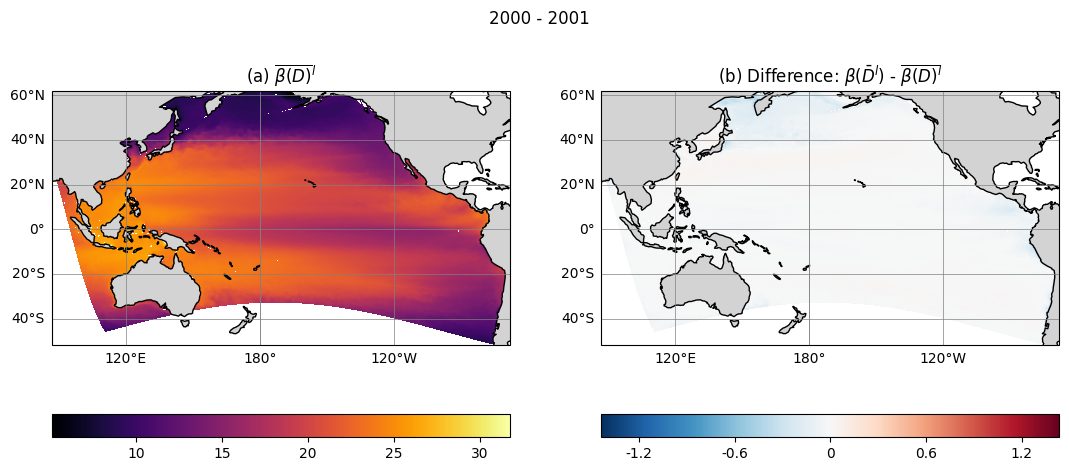

In [65]:
fig = compare_carbonate_sensitivity_reduced(
    beta_mean, ds_mean.dDICdCO2, 
    r"$\overline{\beta(D)}^l$", r"$\beta(\bar{D}^l)$",
    suptitle="2000 - 2001"
)

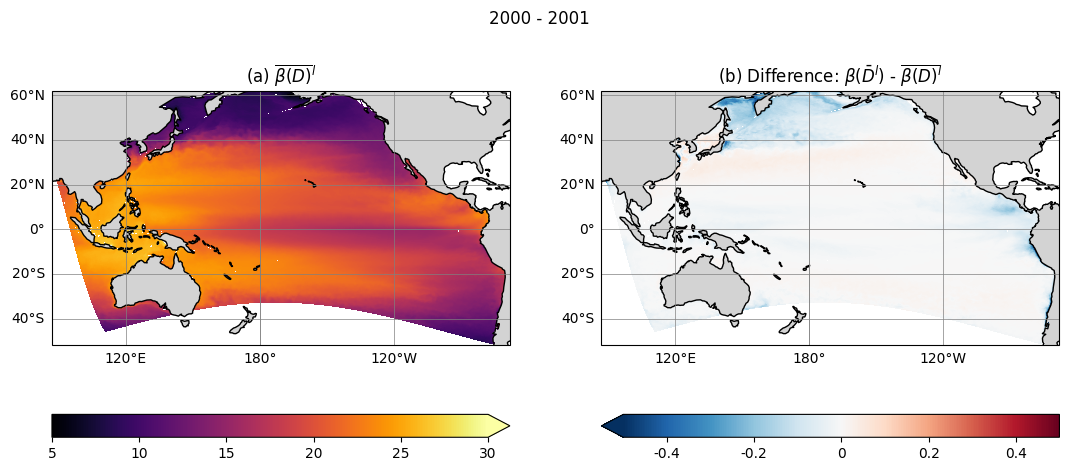

In [66]:
vmin = 5
vmax = 30
kwargs_beta = {"vmin": vmin, "vmax": vmax, "cmap": "inferno"}

vmin = -0.5
vmax = 0.5
kwargs_diff = {"vmin": vmin, "vmax": vmax, "cmap": "RdBu_r"}

fig = compare_carbonate_sensitivity_reduced(
    beta_mean, ds_mean.dDICdCO2, 
    r"$\overline{\beta(D)}^l$", r"$\beta(\bar{D}^l)$",
    kwargs_beta=kwargs_beta, kwargs_diff=kwargs_diff,
    suptitle="2000 - 2001"
)

In [67]:
fig.savefig(
    "figures/long_term_mean_beta_diff.png",
    dpi=300,
    bbox_inches="tight",
)

## Monthly, January 2000 ($\beta$)

In [68]:
beta_monthly = ds_daily.dDICdCO2.groupby(["time.year", "time.month"]).mean("time")

In [69]:
eta_monthly = ds_daily.dDICdALK.groupby(["time.year", "time.month"]).mean("time")

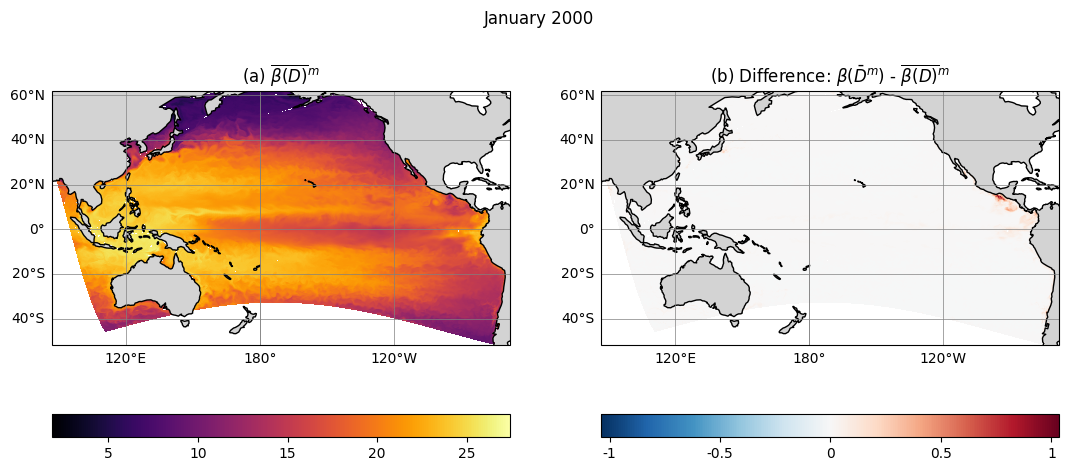

In [70]:
fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jan2000.dDICdCO2, 
    beta_monthly.isel(year=0, month=0).squeeze(), 
    r"$\overline{\beta(D)}^m$", 
    r"$\beta(\bar{D}^m)$",
    suptitle="January 2000"
)

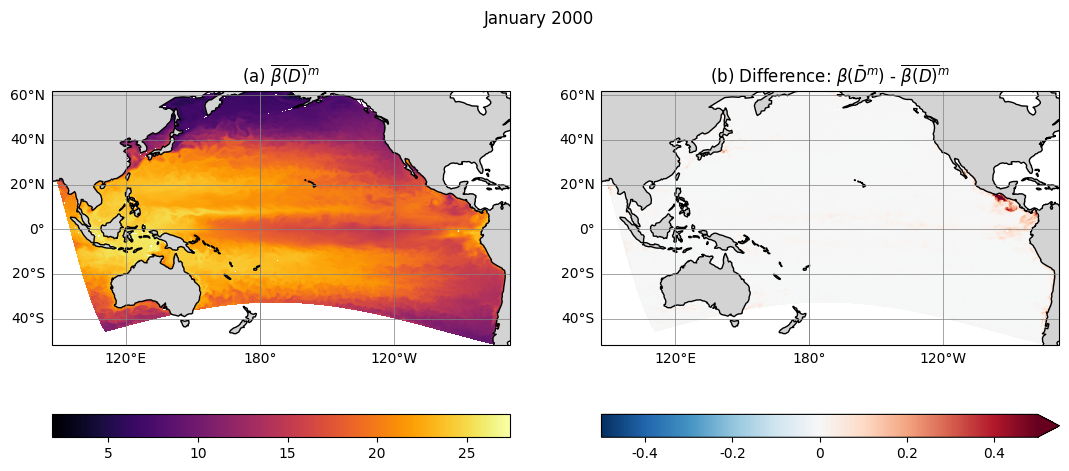

In [71]:
vmin = -0.5
vmax = 0.5
kwargs_diff = {"vmin": vmin, "vmax": vmax, "cmap": "RdBu_r"}

fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jan2000.dDICdCO2, 
    beta_monthly.isel(year=0, month=0).squeeze(), 
    r"$\overline{\beta(D)}^m$", 
    r"$\beta(\bar{D}^m)$",
    kwargs_diff=kwargs_diff,
    suptitle="January 2000"
)

In [72]:
fig.savefig(
    "figures/monthly_beta_Jan2000_diff.png",
    dpi=300,
    bbox_inches="tight",
)

## Monthly, July 2000 ($\beta$)

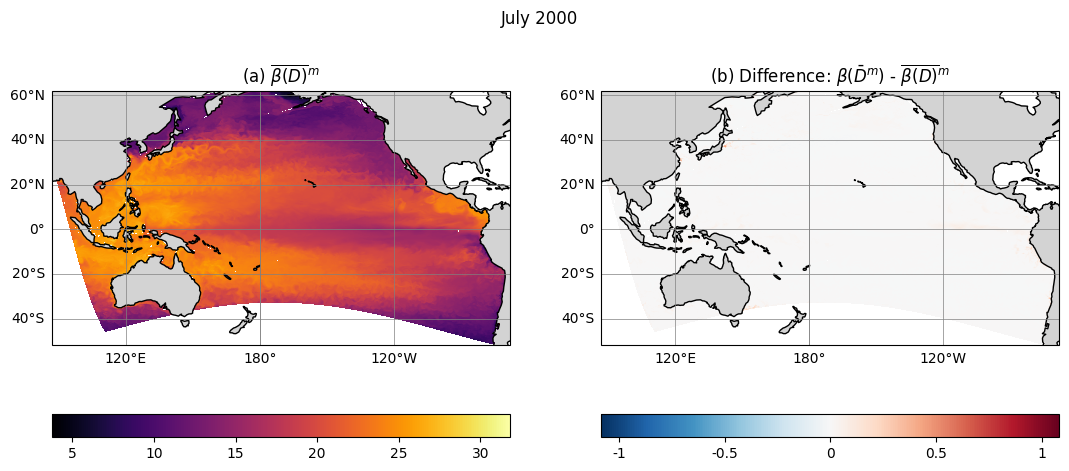

In [73]:
fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jul2000.dDICdCO2, 
    beta_monthly.isel(year=0, month=6).squeeze(), 
    r"$\overline{\beta(D)}^m$", 
    r"$\beta(\bar{D}^m)$",
    suptitle="July 2000"
)

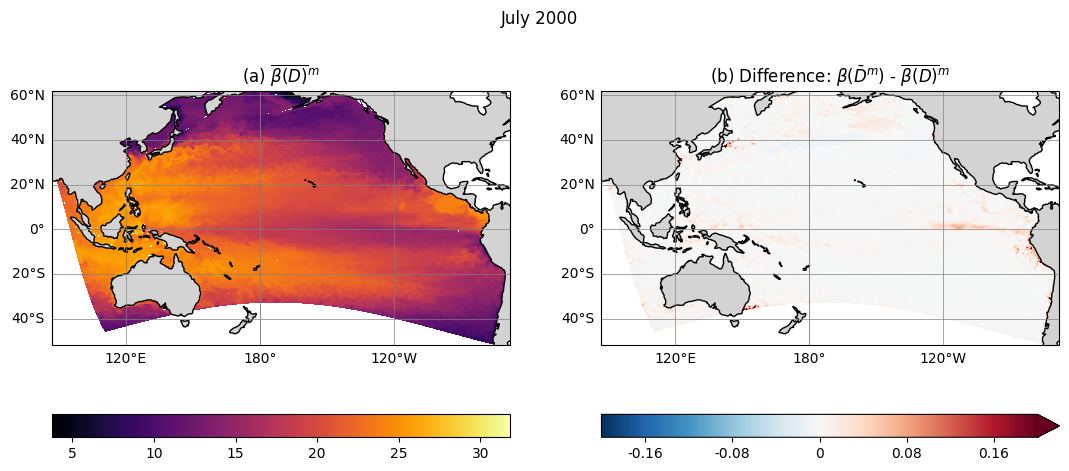

In [74]:
vmin = -0.2
vmax = 0.2
kwargs_diff = {"vmin": vmin, "vmax": vmax, "cmap": "RdBu_r"}

fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jul2000.dDICdCO2, 
    beta_monthly.isel(year=0, month=6).squeeze(), 
    r"$\overline{\beta(D)}^m$", 
    r"$\beta(\bar{D}^m)$",
    kwargs_diff=kwargs_diff,
    suptitle="July 2000"
)

In [75]:
fig.savefig(
    "figures/monthly_beta_Jul2000_diff.png",
    dpi=300,
    bbox_inches="tight",
)

# $\eta(\bar{D})$ vs. $\overline{\eta(D)}$

## Long-term mean ($\eta$)

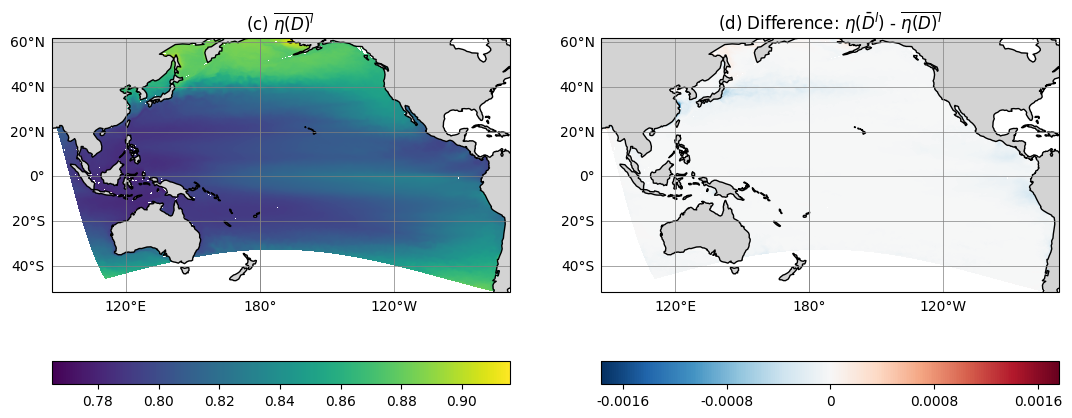

In [76]:
fig = compare_carbonate_sensitivity_reduced(eta_mean, ds_mean.dDICdALK, r"$\overline{\eta(D)}^l$", r"$\eta(\bar{D}^l)$", beta=False)

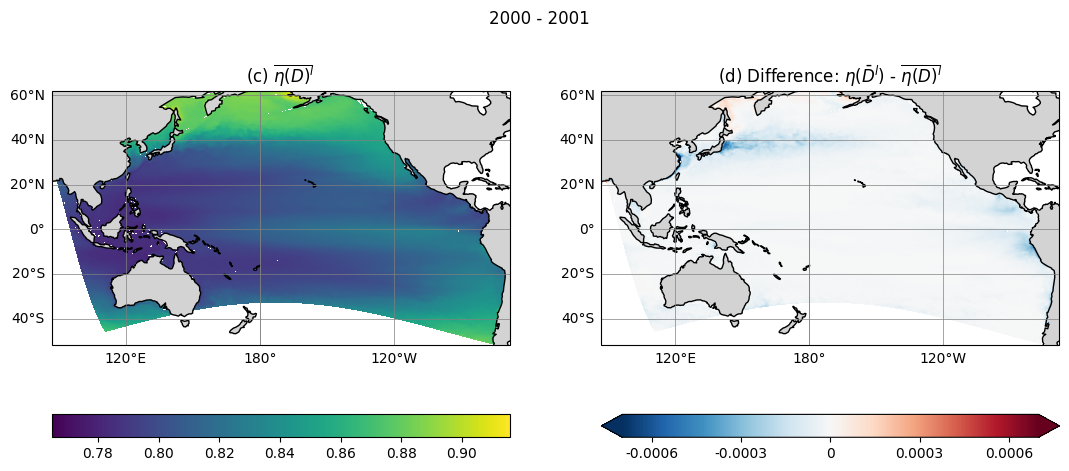

In [77]:
vmin = -0.0007
vmax = 0.0007
kwargs_diff = {"vmin": vmin, "vmax": vmax, "cmap": "RdBu_r"}

fig = compare_carbonate_sensitivity_reduced(
    eta_mean, ds_mean.dDICdALK, 
    r"$\overline{\eta(D)}^l$", r"$\eta(\bar{D}^l)$",
    beta=False,
    kwargs_diff=kwargs_diff,
    suptitle="2000 - 2001"
)

In [78]:
fig.savefig(
    "figures/long_term_mean_eta_diff.png",
    dpi=300,
    bbox_inches="tight",
)

## Monthly, January 2000 ($\eta$)

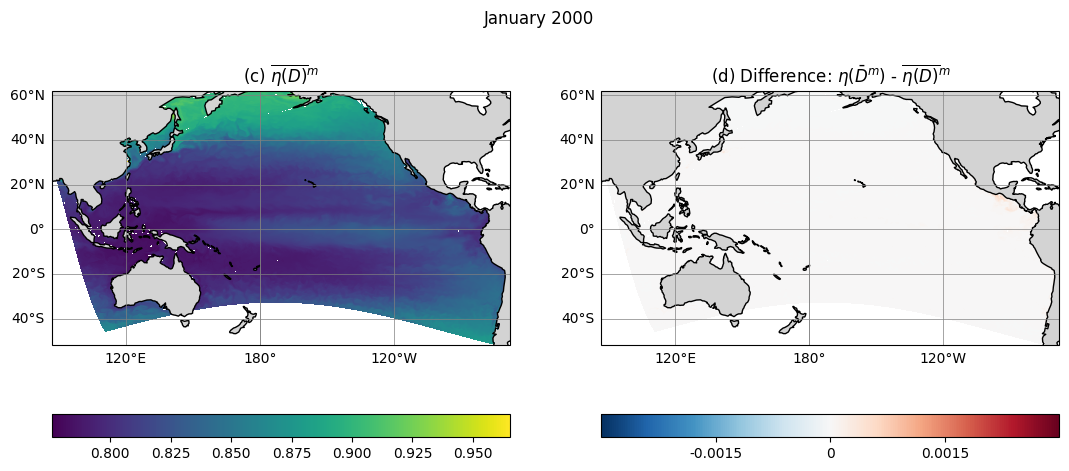

In [79]:
fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jan2000.dDICdALK, 
    eta_monthly.isel(year=0, month=0).squeeze(), 
    r"$\overline{\eta(D)}^m$", 
    r"$\eta(\bar{D}^m)$",
    beta=False,
    suptitle="January 2000"
)

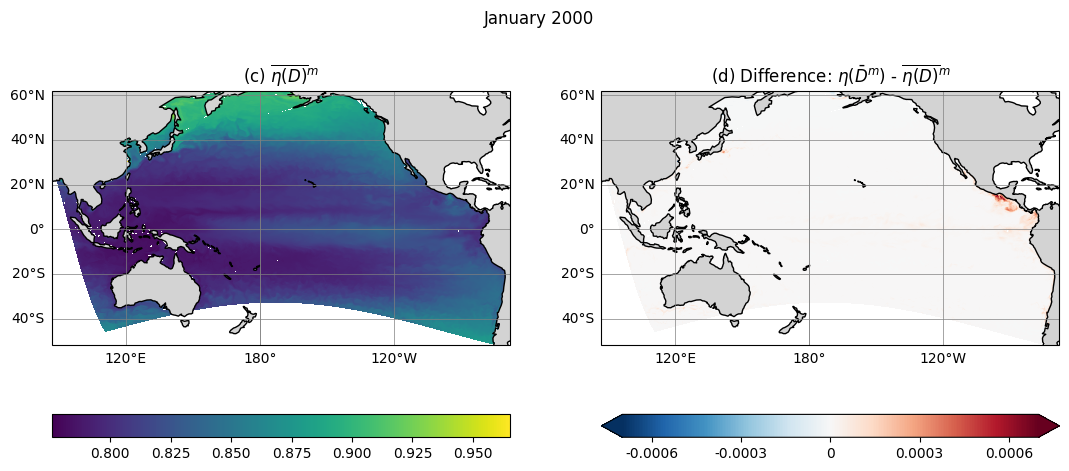

In [80]:
vmin = -0.0007
vmax = 0.0007
kwargs_diff = {"vmin": vmin, "vmax": vmax, "cmap": "RdBu_r"}

fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jan2000.dDICdALK, 
    eta_monthly.isel(year=0, month=0).squeeze(), 
    r"$\overline{\eta(D)}^m$", 
    r"$\eta(\bar{D}^m)$",
    beta=False,
    kwargs_diff=kwargs_diff,
    suptitle="January 2000"
)

In [81]:
fig.savefig(
    "figures/monthly_eta_Jan2000_diff.png",
    dpi=300,
    bbox_inches="tight",
)

## Monthly, July 2000 ($\eta$)

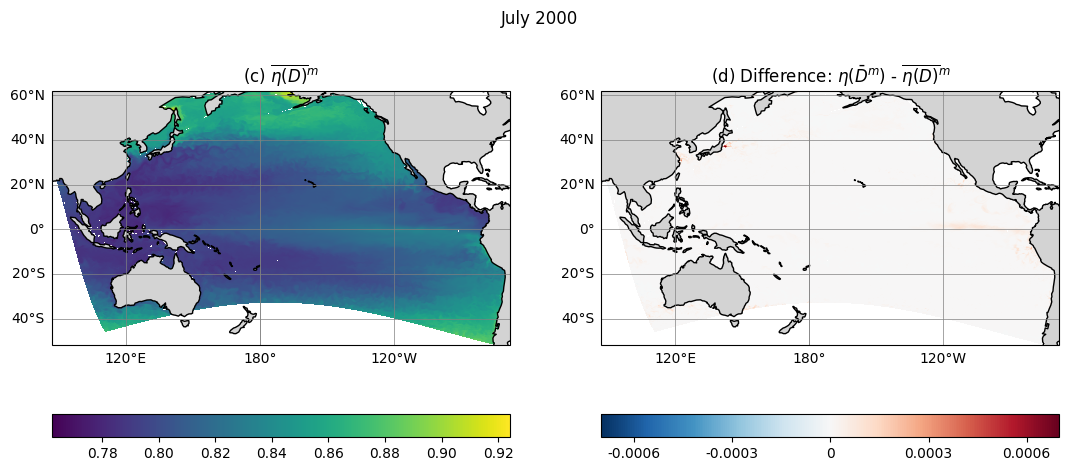

In [82]:
fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jul2000.dDICdALK, 
    eta_monthly.isel(year=0, month=6).squeeze(), 
    r"$\overline{\eta(D)}^m$", 
    r"$\eta(\bar{D}^m)$",
    beta=False,
    kwargs_diff=kwargs_diff,
    suptitle="July 2000"
)

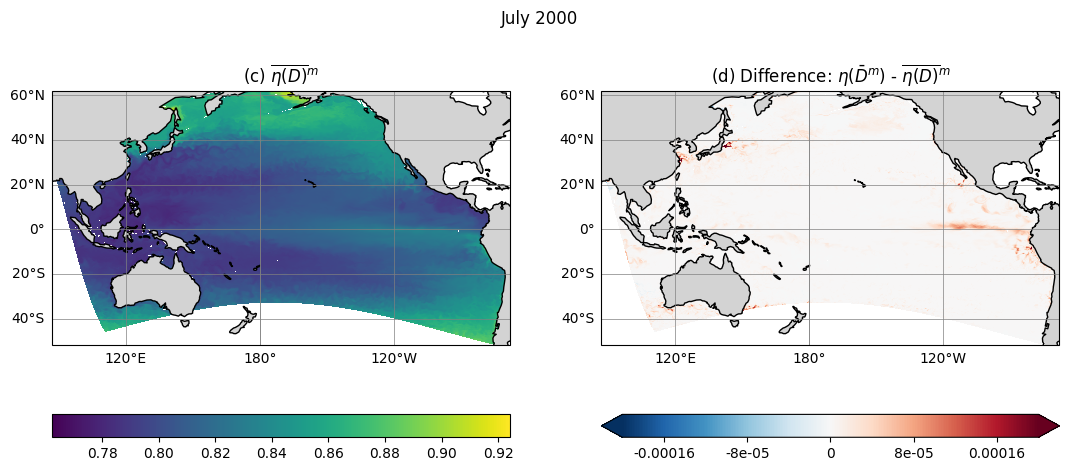

In [83]:
vmin = -0.0002
vmax = 0.0002
kwargs_diff = {"vmin": vmin, "vmax": vmax, "cmap": "RdBu_r"}

fig = compare_carbonate_sensitivity_reduced(
    ds_monthly_Jul2000.dDICdALK, 
    eta_monthly.isel(year=0, month=6).squeeze(), 
    r"$\overline{\eta(D)}^m$", 
    r"$\eta(\bar{D}^m)$",
    beta=False,
    kwargs_diff=kwargs_diff,
    suptitle="July 2000"
)

In [84]:
fig.savefig(
    "figures/monthly_eta_Jul2000_diff.png",
    dpi=300,
    bbox_inches="tight",
)